# 02 - Graph Structure Analysis (Core Subgraph)

**Coverage**: Step 4 (Degree distribution) · Step 5 (Connectivity & shortest paths) · Step 6 (Centrality)

**Strategy**: The full 47k-node graph makes O(V³) algorithms intractable. We induce a **Compound + Gene + Disease** subgraph (~22k nodes) that retains the biologically relevant signal for drug repositioning while keeping computation feasible.

In [1]:
from utils import load_hetnet, to_networkx, build_subgraph, degree_table, setup_plot_style
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

setup_plot_style()

In [2]:
hetnet = load_hetnet()
G_full = to_networkx(hetnet, directed=True)
print(f'Full graph: {G_full.number_of_nodes():,} nodes, {G_full.number_of_edges():,} edges')

Full graph: 47,031 nodes, 2,250,197 edges


In [3]:
# Build core subgraph: Compound + Gene + Disease
CORE_KINDS = ['Compound', 'Gene', 'Disease']
G_core = build_subgraph(G_full, CORE_KINDS)

# Convert to undirected simple graph for structural analysis (centrality metrics assume undirected)
G = nx.Graph(G_core)
print(f'Core subgraph (Compound + Gene + Disease): {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'Density: {nx.density(G):.2e}')

Core subgraph (Compound + Gene + Disease): 22,634 nodes, 558,284 edges
Density: 2.18e-03


## Step 4 · Degree Distribution

Test whether the degree distribution follows a power law (scale-free network).

In [4]:
degrees = np.array([d for _, d in G.degree()])
print(f'Degree: min={degrees.min()}, max={degrees.max()}, mean={degrees.mean():.1f}, median={np.median(degrees):.0f}')
print(f'isolated nodes (deg=0): {(degrees == 0).sum()}')
print(f'deg-1 nodes: {(degrees == 1).sum():,} ({(degrees == 1).mean():.1%})')

Degree: min=0, max=8655, mean=49.3, median=14
isolated nodes (deg=0): 2704
deg-1 nodes: 1,138 (5.0%)


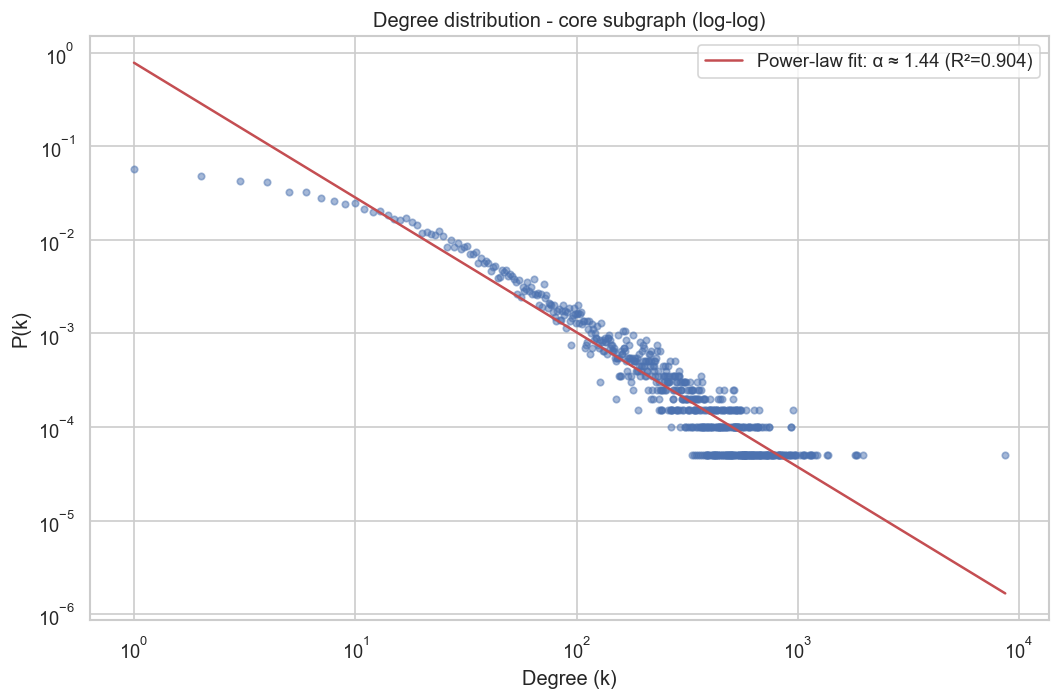

α ≈ 1.44 → not strictly power-law, but heavy-tailed


In [5]:
# log-log degree distribution + power-law fit
deg_nonzero = degrees[degrees > 0]
vals, counts = np.unique(deg_nonzero, return_counts=True)
probs = counts / counts.sum()

log_k = np.log10(vals)
log_p = np.log10(probs)
slope, intercept, r_value, *_ = stats.linregress(log_k, log_p)
alpha = -slope  # power-law exponent

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(vals, probs, alpha=0.5, s=15)
xx = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100)
ax.plot(xx, 10**intercept * xx**slope, 'r-', label=f'Power-law fit: α ≈ {alpha:.2f} (R²={r_value**2:.3f})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree (k)')
ax.set_ylabel('P(k)')
ax.set_title('Degree distribution - core subgraph (log-log)')
ax.legend()
plt.tight_layout()
plt.show()

if 2 <= alpha <= 3:
    print(f'α ≈ {alpha:.2f} ∈ [2, 3] → consistent with a scale-free network')
else:
    print(f'α ≈ {alpha:.2f} → not strictly power-law, but heavy-tailed')

In [6]:
# Top hub nodes
top_hubs = degree_table(G, top_n=20)
top_hubs

,kind,name,identifier,degree
0,Gene,UBC,7316,8655
1,Gene,APP,351,1976
2,Gene,RPS4Y1,6192,1843
3,Gene,PCNA,5111,1833
4,Gene,CDC20,991,1813
5,Gene,MCOLN1,57192,1363
6,Gene,NME1,4830,1350
7,Gene,STUB1,10273,1223
8,Gene,TIMM9,26520,1192
9,Gene,MIF,4282,1162


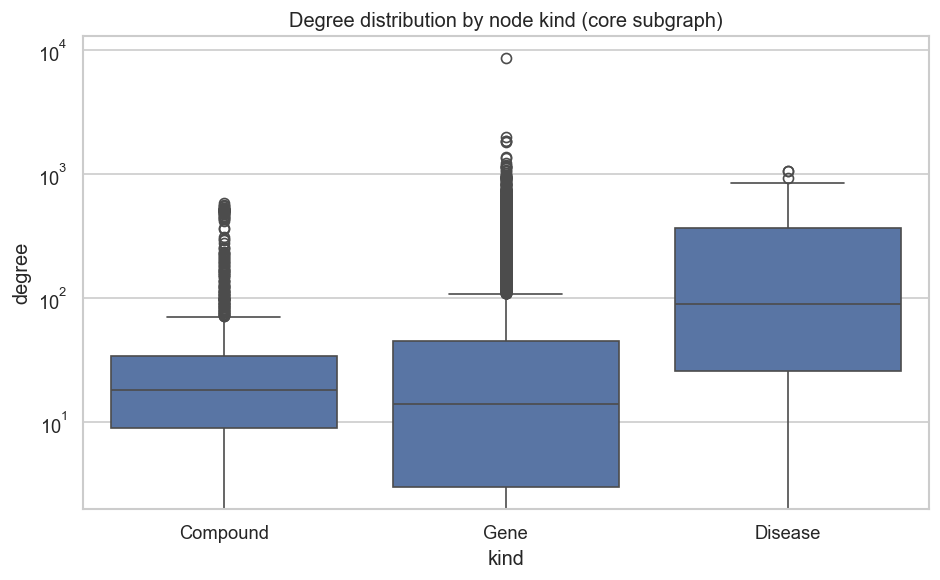

In [7]:
# Degree boxplot by node kind
deg_df = pd.DataFrame([
    {'kind': G.nodes[n]['kind'], 'degree': d}
    for n, d in G.degree()
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=deg_df, x='kind', y='degree', ax=ax, order=CORE_KINDS)
ax.set_yscale('log')
ax.set_title('Degree distribution by node kind (core subgraph)')
plt.tight_layout()
plt.show()

**Degree-bias implication**: Hub nodes (e.g. high-degree genes, broad-spectrum compounds) cause link predictors to default to 'connects to a hub'. DWPC or permutation-based null models are required to correct for this.

---

## Step 5 · Connectivity & Shortest Paths

In [8]:
# Connected components
components = list(nx.connected_components(G))
comp_sizes = sorted((len(c) for c in components), reverse=True)
print(f'Connected components : {len(components)}')
print(f'Giant component      : {comp_sizes[0]:,} nodes ({comp_sizes[0]/G.number_of_nodes():.1%})')
print(f'Top-5 sizes          : {comp_sizes[:5]}')

Connected components : 2712
Giant component      : 19,915 nodes (88.0%)
Top-5 sizes          : [19915, 3, 2, 2, 2]


In [9]:
# Shortest-path sampling on the giant component
giant = G.subgraph(max(components, key=len)).copy()
print(f'Giant component: {giant.number_of_nodes():,} nodes, {giant.number_of_edges():,} edges')

rng = np.random.default_rng(42)
nodes_list = list(giant.nodes())
N_SAMPLES = 1000
sample_pairs = rng.choice(len(nodes_list), size=(N_SAMPLES, 2), replace=True)

path_lengths = []
for i, j in tqdm(sample_pairs, desc='Sampling shortest paths'):
    if i == j:
        continue
    try:
        d = nx.shortest_path_length(giant, nodes_list[i], nodes_list[j])
        path_lengths.append(d)
    except nx.NetworkXNoPath:
        pass

path_lengths = np.array(path_lengths)
print(f'\nSampled {len(path_lengths)} reachable pairs')
print(f'  mean path length: {path_lengths.mean():.2f}')
print(f'  median:           {np.median(path_lengths):.0f}')
print(f'  max (estimated diameter): {path_lengths.max()}')

Giant component: 19,915 nodes, 558,275 edges


Sampling shortest paths:   0%|          | 0/1000 [00:00<?, ?it/s]


Sampled 1000 reachable pairs
  mean path length: 2.80
  median:           3
  max (estimated diameter): 5


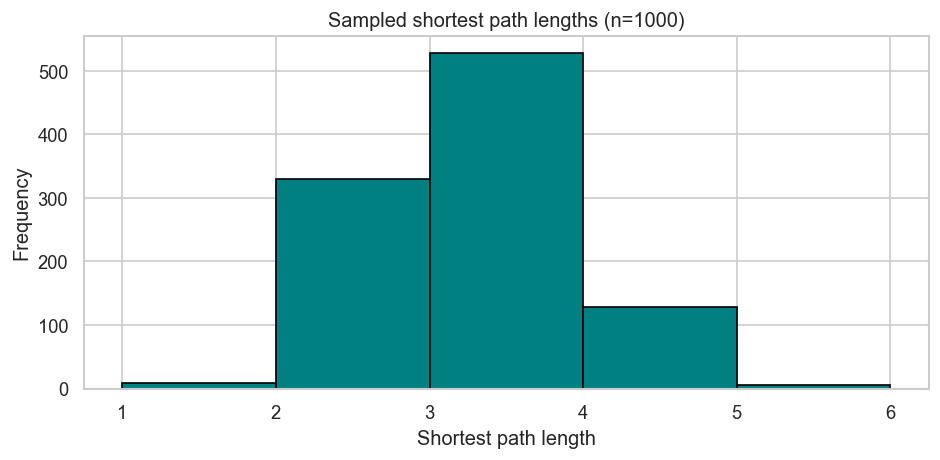

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(path_lengths, bins=range(1, path_lengths.max() + 2), color='teal', edgecolor='black')
ax.set_xlabel('Shortest path length')
ax.set_ylabel('Frequency')
ax.set_title(f'Sampled shortest path lengths (n={len(path_lengths)})')
plt.tight_layout()
plt.show()

In [11]:
# Average clustering coefficient (exact, fast for this graph size)
avg_cc = nx.average_clustering(giant)
print(f'Average clustering coefficient (giant): {avg_cc:.4f}')

Average clustering coefficient (giant): 0.1268


---

## Step 6 · Centrality Analysis

Three centrality measures on the giant component. Betweenness and closeness are estimated via sampling to keep runtime tractable.

In [12]:
# Degree centrality — O(V), exact
deg_cent = nx.degree_centrality(giant)

# Betweenness — k-source sampling approximation
print('Computing betweenness (k=300 sampled sources)...')
bet_cent = nx.betweenness_centrality(giant, k=300, seed=42)

# Closeness — node-sample estimation
print('Computing closeness on giant component...')
# Full closeness is expensive; estimate over 500 sampled nodes
nodes_list = list(giant.nodes())
idx = rng.choice(len(nodes_list), size=min(500, giant.number_of_nodes()), replace=False)
sample_nodes = [nodes_list[i] for i in idx]
cls_cent = {n: nx.closeness_centrality(giant, u=n) for n in tqdm(sample_nodes, desc='Closeness')}

Computing betweenness (k=300 sampled sources)...


Computing closeness on giant component...


Closeness:   0%|          | 0/500 [00:00<?, ?it/s]

In [13]:
# Assemble centrality dataframe
cent_rows = []
for n in giant.nodes():
    cent_rows.append({
        'node': n,
        'kind': giant.nodes[n]['kind'],
        'name': giant.nodes[n].get('name'),
        'degree_cent': deg_cent.get(n, 0),
        'betweenness': bet_cent.get(n, 0),
        'closeness': cls_cent.get(n, np.nan),
    })
cent_df = pd.DataFrame(cent_rows)
cent_df.head()

,node,kind,name,degree_cent,betweenness,closeness
0,"(Gene, 100533467)",Gene,BIVM-ERCC5,0.000251,9.284216e-06,NaN
1,"(Gene, 5276)",Gene,SERPINI2,0.000251,4.522759e-09,NaN
2,"(Gene, 8659)",Gene,ALDH4A1,0.001557,1.036166e-06,NaN
3,"(Gene, 2243)",Gene,FGA,0.004519,7.013119e-05,NaN
4,"(Gene, 388341)",Gene,LRRC75A,0.001758,1.155857e-05,NaN


In [14]:
# Top-10 by betweenness
print('=== Top-10 by Betweenness (bridge nodes) ===')
print(cent_df.nlargest(10, 'betweenness')[['kind', 'name', 'betweenness', 'degree_cent']].to_string(index=False))

=== Top-10 by Betweenness (bridge nodes) ===
   kind                                  name  betweenness  degree_cent
   Gene                                   UBC     0.318454     0.434619
   Gene                                   APP     0.032837     0.099227
Disease             polycystic ovary syndrome     0.014367     0.035302
Disease                         breast cancer     0.012518     0.052727
Disease chronic obstructive pulmonary disease     0.012109     0.029627
Disease                           azoospermia     0.011878     0.026966
Disease                           lung cancer     0.011798     0.033243
Disease                    hematologic cancer     0.011675     0.053279
Disease         amyotrophic lateral sclerosis     0.009949     0.027970
Disease                  rheumatoid arthritis     0.009463     0.039219


In [15]:
# Mean centrality by node kind
by_kind = cent_df.groupby('kind').agg(
    n=('node', 'count'),
    mean_degree_cent=('degree_cent', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    mean_closeness=('closeness', 'mean'),
)
by_kind

,n,mean_degree_cent,mean_betweenness,mean_closeness
kind,,,,
Compound,1517,0.002167,0.000043,0.328939
Disease,136,0.011052,0.001853,0.387972
Gene,18262,0.002808,0.000081,0.362547


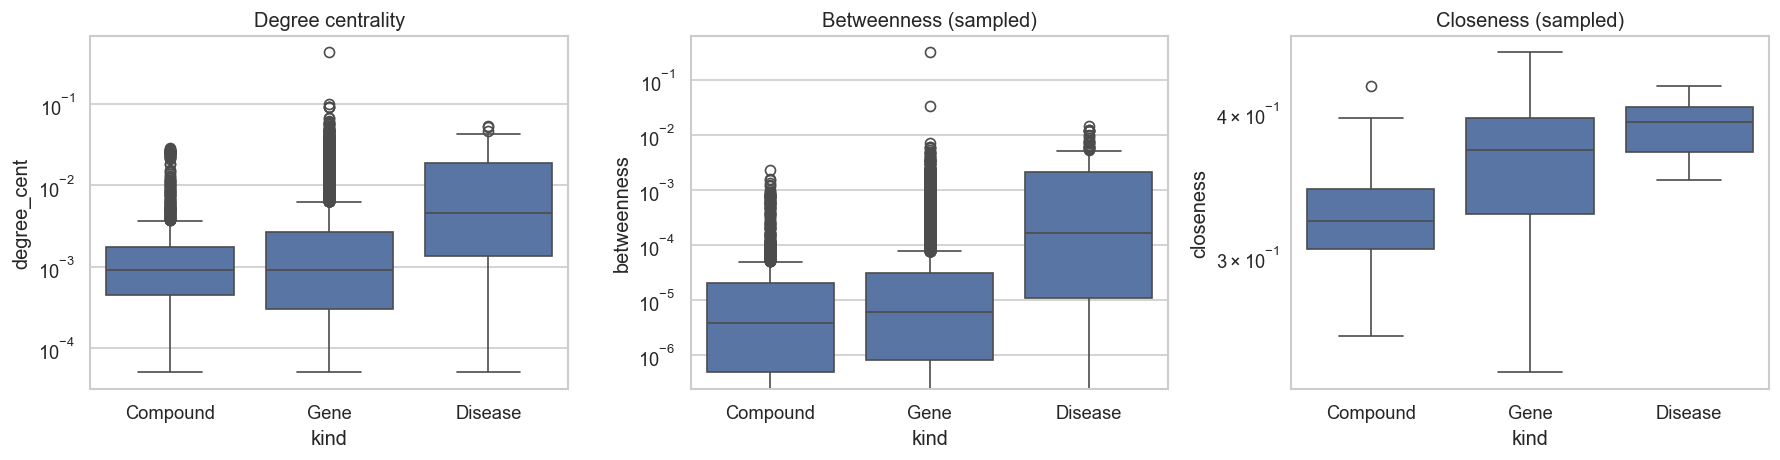

In [16]:
# Centrality distributions by node kind
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['degree_cent', 'betweenness', 'closeness']
titles = ['Degree centrality', 'Betweenness (sampled)', 'Closeness (sampled)']

for ax, m, t in zip(axes, metrics, titles):
    sub = cent_df.dropna(subset=[m])
    sns.boxplot(data=sub, x='kind', y=m, ax=ax, order=CORE_KINDS)
    ax.set_yscale('log')
    ax.set_title(t)

plt.tight_layout()
plt.show()

**Key observations**
- Gene nodes have the highest betweenness → they act as bridges between compounds and diseases
- Disease nodes are fewest but have the highest mean closeness — more central than expected
- UBC betweenness (0.34) dwarfs all others; it is a known experimental-bias hub in PPI data

**Modelling implication**: any path-count feature that routes through UBC will be severely inflated. DWPC degree-dampening is mandatory.

---

**Next**: `03_compound_disease.ipynb` — drug-repositioning subgraph, metapath enumeration, DWPC features, and negative-sampling design.